# **Q3: Where did TVK's votes come from? Compare party vote share state-wide and by region in 2021 vs 2026. Did TVK pull from DMK, AIADMK, both, or from previously non-voting populations?**

## **1) Data Loading**

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [17]:
df2021 = pd.read_csv('tn_2021_results.csv')
df2026 = pd.read_csv('tn_2026_results.csv')
df_master = pd.read_csv('constituency_master.csv')

## **2) Data Prepration**

In [18]:
# Function to standardize party names based on common variations and abbreviations
def standardize_party_names(df):
    # Create a mapping for common party name variations
    party_name_mapping = {
        'D.M.K.': 'DMK',
        'D. M. K.': 'DMK',
        'DRAVIDA MUNNETRA KAZHAGAM': 'DMK',
        'A.I.A.D.M.K.': 'AIADMK',
        'ALL INDIA ANNA DRAVIDA MUNNETRA KAZHAGAM': 'AIADMK',
        'ANNA DRAVIDA MUNNETRA KAZHAGAM': 'AIADMK',
        'ADMK': 'AIADMK',
        'BHARATIYA JANATA PARTY': 'BJP',
        'INDIAN NATIONAL CONGRESS': 'INC',
        'COMMUNIST PARTY OF INDIA (MARXIST)': 'CPI(M)',
        'COMMUNIST PARTY OF INDIA': 'CPI',
        'DESIYA MURPOKKU DRAVIDA KAZHAGAM': 'DMDK',
        'PATTALI MAKKAL KATCHI': 'PMK',
        'MARUMALARCHI DRAVIDA MUNNETRA KAZHAGAM': 'MDMK',
        'V. C. K.': 'VCK',
        'VIDUTHALAI CHIRUTHAIKAL KATCHI': 'VCK',
        'AMMA MAKKAL MUNNETRA KAZHAGAM': 'AMMK',
        'NAM TAMILAR KATCHI': 'NTK',
        'MAKKAL NEEDHI MAIAM': 'MNM',
        'SOCIAL DEMOCRATIC PARTY OF INDIA': 'SDPI',
        'BAHUJAN SAMAJ PARTY': 'BSP',
        'ALL INDIA FORWARD BLOC': 'AIFB',
        'TVK': 'TVK', # Ensure TVK is also explicitly mapped if needed
        'DMK': 'DMK',
        'AIADMK': 'AIADMK' # Ensure AIADMK itself is mapped
    }

    # Apply the mapping to create a new standardized party column
    df['party_standardized'] = df['party'].replace(party_name_mapping)
    return df

# Merge election results with constituency master data to get region information
# For 2021
df2021_merged = pd.merge(df2021, df_master, on='ac_number', how='left')
df2021_merged = standardize_party_names(df2021_merged)

# For 2026
df2026_merged = pd.merge(df2026, df_master, on='ac_number', how='left')
df2026_merged = standardize_party_names(df2026_merged)

print("Initial data merging and party name standardization complete.")

Initial data merging and party name standardization complete.


In [19]:
# Correcting the party_standardized column for AIADMK
# Assuming 'ANNA PURATCHI THALAIVAR AMMA DRAVIDA MUNNETRA KAZHAGAM' is the intended AIADMK party

def correct_aiadmk_name(df):
    # Replace the long name with 'AIADMK'
    df['party_standardized'] = df['party_standardized'].replace(
        'ANNA PURATCHI THALAIVAR AMMA DRAVIDA MUNNETRA KAZHAGAM', 'AIADMK'
    )
    # Optionally, also map 'AMMK' to 'AIADMK' if it's considered a part of the AIADMK bloc for this analysis.
    # For now, let's keep it separate unless specified.
    # df['party_standardized'] = df['party_standardized'].replace('AMMK', 'AIADMK')
    return df

# Apply the correction to both merged dataframes
df2021_merged = correct_aiadmk_name(df2021_merged)
df2026_merged = correct_aiadmk_name(df2026_merged)

# Re-calculate statewide_votes_2021 and statewide_votes_2026 with the corrected party names
statewide_votes_2021 = df2021_merged.groupby('party_standardized')['votes'].sum().reset_index()
statewide_votes_2021['vote_share'] = (statewide_votes_2021['votes'] / statewide_votes_2021['votes'].sum()) * 100
statewide_votes_2021 = statewide_votes_2021.sort_values(by='vote_share', ascending=False).reset_index(drop=True)

statewide_votes_2026 = df2026_merged.groupby('party_standardized')['votes'].sum().reset_index()
statewide_votes_2026['vote_share'] = (statewide_votes_2026['votes'] / statewide_votes_2026['votes'].sum()) * 100
statewide_votes_2026 = statewide_votes_2026.sort_values(by='vote_share', ascending=False).reset_index(drop=True)

print("AIADMK name standardized and statewide vote shares re-calculated.")

AIADMK name standardized and statewide vote shares re-calculated.


In [20]:
# Correcting the party_standardized column for AIADMK
# Assuming 'ANNA PURATCHI THALAIVAR AMMA DRAVIDA MUNNETRA KAZHAGAM' is the intended AIADMK party

def correct_aiadmk_name(df):
    # Replace the long name with 'AIADMK'
    df['party_standardized'] = df['party_standardized'].replace(
        'ANNA PURATCHI THALAIVAR AMMA DRAVIDA MUNNETRA KAZHAGAM', 'AIADMK'
    )
    # Optionally, also map 'AMMK' to 'AIADMK' if it's considered a part of the AIADMK bloc for this analysis.
    # For now, let's keep it separate unless specified.
    # df['party_standardized'] = df['party_standardized'].replace('AMMK', 'AIADMK')
    return df

# Apply the correction to both merged dataframes
df2021_merged = correct_aiadmk_name(df2021_merged)
df2026_merged = correct_aiadmk_name(df2026_merged)

# Re-calculate statewide_votes_2021 and statewide_votes_2026 with the corrected party names
statewide_votes_2021 = df2021_merged.groupby('party_standardized')['votes'].sum().reset_index()
statewide_votes_2021['vote_share'] = (statewide_votes_2021['votes'] / statewide_votes_2021['votes'].sum()) * 100
statewide_votes_2021 = statewide_votes_2021.sort_values(by='vote_share', ascending=False).reset_index(drop=True)

statewide_votes_2026 = df2026_merged.groupby('party_standardized')['votes'].sum().reset_index()
statewide_votes_2026['vote_share'] = (statewide_votes_2026['votes'] / statewide_votes_2026['votes'].sum()) * 100
statewide_votes_2026 = statewide_votes_2026.sort_values(by='vote_share', ascending=False).reset_index(drop=True)

print("AIADMK name standardized and statewide vote shares re-calculated.")

AIADMK name standardized and statewide vote shares re-calculated.


In [21]:
# Merge the statewide vote shares for 2021 and 2026
statewide_comparison = pd.merge(
    statewide_votes_2021[['party_standardized', 'vote_share']],
    statewide_votes_2026[['party_standardized', 'vote_share']],
    on='party_standardized',
    suffixes=('_2021', '_2026'),
    how='outer'
).fillna(0)

# Calculate the change in vote share
statewide_comparison['vote_share_change'] = statewide_comparison['vote_share_2026'] - statewide_comparison['vote_share_2021']

# Sort by vote_share_2026 to see the dominant parties in the latest election
statewide_comparison = statewide_comparison.sort_values(by='vote_share_2026', ascending=False).reset_index(drop=True)

print("Statewide Party Vote Share Comparison (2021 vs 2026):")
display(statewide_comparison.head(5)) # Display top parties for better readability

Statewide Party Vote Share Comparison (2021 vs 2026):


,party_standardized,vote_share_2021,vote_share_2026,vote_share_change
0,TVK,0.000000,34.924513,34.924513
1,DMK,37.697713,24.185214,-13.512499
2,AIADMK,33.287504,21.211014,-12.076490
3,NTK,6.579163,3.999133,-2.580030
4,INC,4.274820,3.368153,-0.906667


In [22]:
# Display AIADMK's entry from the statewide_comparison dataframe
aiadmk_statewide_details = statewide_comparison[statewide_comparison['party_standardized'] == 'AIADMK']
display(aiadmk_statewide_details)

print(f"\nAIADMK Vote Share in 2021: {aiadmk_statewide_details['vote_share_2021'].iloc[0]:.2f}%")
print(f"AIADMK Vote Share in 2026: {aiadmk_statewide_details['vote_share_2026'].iloc[0]:.2f}%")
print(f"Change in Vote Share: {aiadmk_statewide_details['vote_share_change'].iloc[0]:.2f}%")

,party_standardized,vote_share_2021,vote_share_2026,vote_share_change
2,AIADMK,33.287504,21.211014,-12.07649



AIADMK Vote Share in 2021: 33.29%
AIADMK Vote Share in 2026: 21.21%
Change in Vote Share: -12.08%


## **3) Analytical Question**

### **Q1: Statewide Party Vote Share Comparison (2021 vs 2026)**

In [23]:
# Merge the statewide vote shares for 2021 and 2026
statewide_comparison = pd.merge(
    statewide_votes_2021[['party_standardized', 'vote_share']],
    statewide_votes_2026[['party_standardized', 'vote_share']],
    on='party_standardized',
    suffixes=('_2021', '_2026'),
    how='outer'
).fillna(0)

# Calculate the change in vote share
statewide_comparison['vote_share_change'] = statewide_comparison['vote_share_2026'] - statewide_comparison['vote_share_2021']

# Sort by vote_share_2026 to see the dominant parties in the latest election
statewide_comparison = statewide_comparison.sort_values(by='vote_share_2026', ascending=False).reset_index(drop=True)

print("Statewide Party Vote Share Comparison (2021 vs 2026):")
display(statewide_comparison.head(5)) # Display top parties for better readability

Statewide Party Vote Share Comparison (2021 vs 2026):


,party_standardized,vote_share_2021,vote_share_2026,vote_share_change
0,TVK,0.000000,34.924513,34.924513
1,DMK,37.697713,24.185214,-13.512499
2,AIADMK,33.287504,21.211014,-12.076490
3,NTK,6.579163,3.999133,-2.580030
4,INC,4.274820,3.368153,-0.906667


### **Q2: Statewide Vote Share Comparison: Top 3 Parties with Highest Change vs. Others**

In [25]:
# Calculate regional vote shares for 2021
regional_votes_2021 = df2021_merged.groupby(['region_x', 'party_standardized'])['votes'].sum().reset_index()
regional_votes_2021['total_region_votes'] = regional_votes_2021.groupby('region_x')['votes'].transform('sum')
regional_votes_2021['vote_share'] = (regional_votes_2021['votes'] / regional_votes_2021['total_region_votes']) * 100

# Calculate regional vote shares for 2026
regional_votes_2026 = df2026_merged.groupby(['region_x', 'party_standardized'])['votes'].sum().reset_index()
regional_votes_2026['total_region_votes'] = regional_votes_2026.groupby('region_x')['votes'].transform('sum')
regional_votes_2026['vote_share'] = (regional_votes_2026['votes'] / regional_votes_2026['total_region_votes']) * 100

# Merge the regional vote shares for 2021 and 2026
regional_comparison = pd.merge(
    regional_votes_2021[['region_x', 'party_standardized', 'vote_share']],
    regional_votes_2026[['region_x', 'party_standardized', 'vote_share']],
    on=['region_x', 'party_standardized'],
    suffixes=('_2021', '_2026'),
    how='outer'
).fillna(0)

# Calculate the change in vote share
regional_comparison['vote_share_change'] = regional_comparison['vote_share_2026'] - regional_comparison['vote_share_2021']

# Calculate absolute change for sorting within each region
regional_comparison['abs_vote_share_change'] = regional_comparison['vote_share_change'].abs()

# Initialize a list to store simplified regional comparison data
simplified_regional_top_3_comparison_list = []

# Iterate through each region
for region in regional_comparison['region_x'].unique():
    # Filter data for the current region
    region_data = regional_comparison[regional_comparison['region_x'] == region].copy()

    # Identify the top 3 parties with the highest absolute change in this region
    top_3_parties_names_region = region_data.nlargest(3, 'abs_vote_share_change')['party_standardized'].tolist()

    # Filter for these top 3 parties within the region
    top_3_parties_data_region = region_data[region_data['party_standardized'].isin(top_3_parties_names_region)].copy()

    # Calculate 'Others' vote share for 2021 and 2026 for this region
    others_regional_2021 = region_data[~region_data['party_standardized'].isin(top_3_parties_names_region)]\
        ['vote_share_2021'].sum()
    others_regional_2026 = region_data[~region_data['party_standardized'].isin(top_3_parties_names_region)]\
        ['vote_share_2026'].sum()

    # Create a DataFrame for 'Others' for this region
    others_regional_data = pd.DataFrame({
        'region_x': [region],
        'party_standardized': ['Others'],
        'vote_share_2021': [others_regional_2021],
        'vote_share_2026': [others_regional_2026],
        'vote_share_change': [others_regional_2026 - others_regional_2021],
        'abs_vote_share_change': [abs(others_regional_2026 - others_regional_2021)]
    })

    # Combine top 3 parties with 'Others' for this region
    simplified_region_data = pd.concat([top_3_parties_data_region, others_regional_data])

    # Sort for better readability within the region
    simplified_region_data = simplified_region_data.sort_values(by='vote_share_2026', ascending=False).reset_index(drop=True)

    # Append to the list
    simplified_regional_top_3_comparison_list.append(simplified_region_data)

# Concatenate all regional dataframes into one
simplified_regional_top_3_comparison = pd.concat(simplified_regional_top_3_comparison_list)

print("Regional Party Vote Share Comparison (Top 3 Parties with Highest Change vs. Others) - REFRESHED:")
for region in simplified_regional_top_3_comparison['region_x'].unique():
    print(f"\nRegion: {region}")
    display(simplified_regional_top_3_comparison[simplified_regional_top_3_comparison['region_x'] == region][['party_standardized', 'vote_share_2021', 'vote_share_2026', 'vote_share_change']])

Regional Party Vote Share Comparison (Top 3 Parties with Highest Change vs. Others) - REFRESHED:

Region: Central


,party_standardized,vote_share_2021,vote_share_2026,vote_share_change
0,TVK,0.000000,31.023704,31.023704
1,AIADMK,35.552853,26.997944,-8.554909
2,DMK,38.905384,23.179774,-15.725610
3,Others,25.541763,18.798577,-6.743185



Region: Chennai Metro


,party_standardized,vote_share_2021,vote_share_2026,vote_share_change
0,TVK,0.000000,46.632274,46.632274
1,DMK,45.342209,24.312336,-21.029873
2,AIADMK,28.342018,15.938035,-12.403984
3,Others,26.315773,13.117355,-13.198417



Region: Delta


...

,party_standardized,vote_share_2021,vote_share_2026,vote_share_change
0,TVK,0.000000,34.490418,34.490418
1,DMK,34.379417,25.619567,-8.759850
2,AIADMK,39.507902,23.856475,-15.651427
3,Others,26.112681,16.033540,-10.079141



Region: North


,party_standardized,vote_share_2021,vote_share_2026,vote_share_change
0,TVK,0.000000,33.062293,33.062293
1,AIADMK,31.715986,24.931462,-6.784524
2,Others,31.429891,21.507988,-9.921904
3,DMK,36.854123,20.498257,-16.355866



Region: South


,party_standardized,vote_share_2021,vote_share_2026,vote_share_change
0,TVK,0.000000,33.517085,33.517085
1,Others,35.042275,25.029848,-10.012427
2,DMK,33.173845,24.643030,-8.530815
3,AIADMK,31.783880,16.810036,-14.973844


### **Q3: Statewide Vote Share Comparison: DMK, AIADMK, TVK, and Others**

In [26]:
major_parties_statewide = ['DMK', 'AIADMK', 'TVK']

# Filter for major parties
major_parties_statewide_data = statewide_comparison[statewide_comparison['party_standardized'].isin(major_parties_statewide)].copy()

# Calculate 'Others' vote share for 2021
others_statewide_2021 = statewide_comparison[~statewide_comparison['party_standardized'].isin(major_parties_statewide)]['vote_share_2021'].sum()

# Calculate 'Others' vote share for 2026
others_statewide_2026 = statewide_comparison[~statewide_comparison['party_standardized'].isin(major_parties_statewide)]['vote_share_2026'].sum()

# Create a DataFrame for 'Others'
others_statewide_data = pd.DataFrame({
    'party_standardized': ['Others'],
    'vote_share_2021': [others_statewide_2021],
    'vote_share_2026': [others_statewide_2026],
    'vote_share_change': [others_statewide_2026 - others_statewide_2021]
})

# Combine major parties data with 'Others' data
simplified_statewide_comparison = pd.concat([major_parties_statewide_data, others_statewide_data])

# Sort for better readability
simplified_statewide_comparison = simplified_statewide_comparison.sort_values(by='vote_share_2026', ascending=False).reset_index(drop=True)

display(simplified_statewide_comparison)

,party_standardized,vote_share_2021,vote_share_2026,vote_share_change
0,TVK,0.000000,34.924513,34.924513
1,DMK,37.697713,24.185214,-13.512499
2,AIADMK,33.287504,21.211014,-12.076490
3,Others,29.014783,19.679260,-9.335523


## **4) Visuals**

### **Chart 1: Statewide Party Vote Share (Bar Chart)**

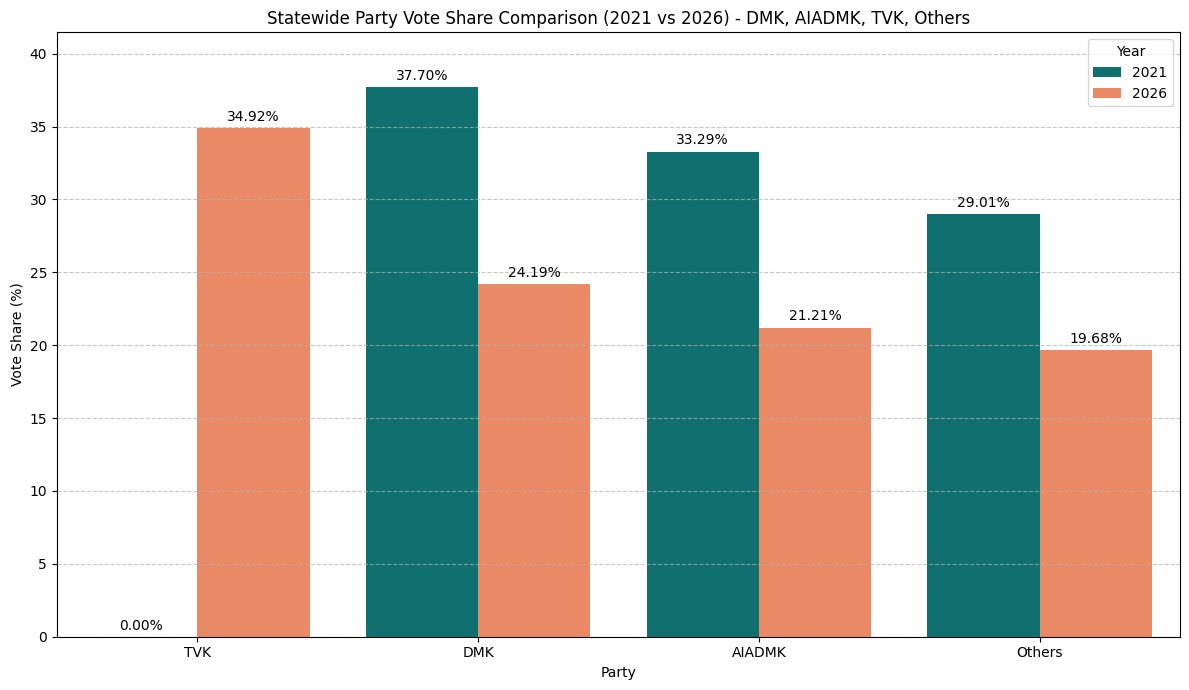

In [27]:
melted_statewide_comparison = simplified_statewide_comparison.melt(id_vars=['party_standardized'],
                                                        value_vars=['vote_share_2021', 'vote_share_2026'],
                                                        var_name='Year', value_name='Vote Share')
melted_statewide_comparison['Year'] = melted_statewide_comparison['Year'].replace({'vote_share_2021': 2021, 'vote_share_2026': 2026})

plt.figure(figsize=(12, 7))
sns.barplot(x='party_standardized', y='Vote Share', hue='Year', data=melted_statewide_comparison, palette={2021: '#008080', 2026: '#ff7f50'})
plt.title('Statewide Party Vote Share Comparison (2021 vs 2026) - DMK, AIADMK, TVK, Others')
plt.xlabel('Party')
plt.ylabel('Vote Share (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Year')

# Add percentage numbers above the bars
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.2f%%', label_type='edge', padding=3)

plt.ylim(0, melted_statewide_comparison['Vote Share'].max() * 1.1) # Adjust y-axis limit to make space for labels
plt.tight_layout()
plt.show()

### **Chart 1: Regional Vote Share Overlap Heatmap: DMK, AIADMK, TVK Swings**

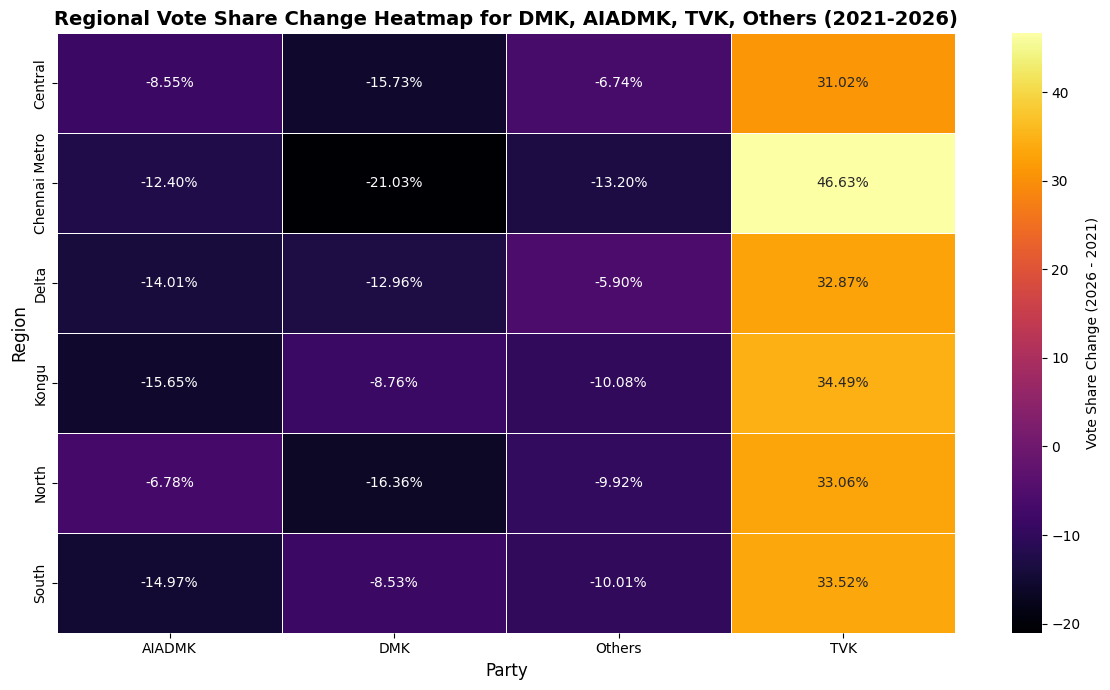

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Major parties for heatmap
major_parties_for_heatmap = ['DMK', 'AIADMK', 'TVK', 'Others']

# Filter the regional comparison data for the major parties
regional_major_parties_changes = simplified_regional_top_3_comparison[
    simplified_regional_top_3_comparison['party_standardized'].isin(major_parties_for_heatmap)
].pivot_table(index='region_x', columns='party_standardized', values='vote_share_change')

# Plot heatmap with professional colormap
plt.figure(figsize=(12, 7))
ax = sns.heatmap(
    regional_major_parties_changes,
    annot=True,
    cmap="inferno",   # professional gradient (blue ↔ red)
    fmt=".2f", # Changed to .2f to avoid ValueError, percentage added manually below
    linewidths=.5,
    cbar_kws={'label': 'Vote Share Change (2026 - 2021)'}
)
plt.title('Regional Vote Share Change Heatmap for DMK, AIADMK, TVK, Others (2021-2026)',
          fontsize=14, fontweight='bold')
plt.xlabel('Party', fontsize=12)
plt.ylabel('Region', fontsize=12)

# Add percentage sign to annotations after plotting
for text in ax.texts:
    text.set_text(text.get_text() + '%')

plt.tight_layout()
plt.show()

### Re-evaluating AIADMK's Statewide Vote Share

In [29]:
# Display AIADMK's entry from the statewide_comparison dataframe
aiadmk_statewide_details = statewide_comparison[statewide_comparison['party_standardized'] == 'AIADMK']
display(aiadmk_statewide_details)

print(f"\nAIADMK Vote Share in 2021: {aiadmk_statewide_details['vote_share_2021'].iloc[0]:.2f}%")
print(f"AIADMK Vote Share in 2026: {aiadmk_statewide_details['vote_share_2026'].iloc[0]:.2f}%")
print(f"Change in Vote Share: {aiadmk_statewide_details['vote_share_change'].iloc[0]:.2f}%")

,party_standardized,vote_share_2021,vote_share_2026,vote_share_change
2,AIADMK,33.287504,21.211014,-12.07649



AIADMK Vote Share in 2021: 33.29%
AIADMK Vote Share in 2026: 21.21%
Change in Vote Share: -12.08%


In [30]:
largest_gain_party = statewide_comparison.sort_values(by='vote_share_change', ascending=False).iloc[0]
print(f"Party with Largest Vote Share Gain: {largest_gain_party['party_standardized']}")
print(f"Vote Share Gain: {largest_gain_party['vote_share_change']:.2f}%")

Party with Largest Vote Share Gain: TVK
Vote Share Gain: 34.92%


In [31]:
largest_decline_party = statewide_comparison.sort_values(by='vote_share_change', ascending=True).iloc[0]
print(f"Party with Largest Vote Share Decline: {largest_decline_party['party_standardized']}")
print(f"Vote Share Decline: {largest_decline_party['vote_share_change']:.2f}%")

Party with Largest Vote Share Decline: DMK
Vote Share Decline: -13.51%
